# Modèles de classification

## Objectifs

- créer des jeux d'entraînement, de validation et de test
- entraîner un modèle Dummy, un modèle linéaire et un modèle non-linéaire
- évaluer chaque modèle sur les jeux d'apprentissage, de validation et de test
- comparer leurs performances
- repérer un éventuel surapprentissage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Chargement des données préparées

Les features `X` et la cible `y` ont été construites dans le notebook précédent  
Le jeu de données est désormais prêt pour l'entraînement des premiers modèles de classification

In [2]:
X = pd.read_csv("../data/processed/X_model.csv")
y = pd.read_csv("../data/processed/y_model.csv").squeeze("columns")

print(X.shape)
print(y.shape)
display(X.head())
display(y.head())

(1470, 39)
(1470,)


,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,5993,8,8,6,4,0,0,1,2,1,0,5,2,3,4,1,1,3,1,11.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,49,5130,1,10,10,7,1,3,8,1,2,1,7,3,2,2,4,3,4,0,23.0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,37,2090,6,7,0,0,0,3,2,2,1,0,0,4,2,3,2,3,3,1,15.0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,33,2909,1,8,8,7,0,3,3,4,2,3,0,4,3,3,3,3,3,1,11.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,27,3468,9,6,2,2,1,3,2,1,1,2,2,1,3,2,4,3,3,0,12.0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


0    1
1    0
2    1
3    0
4    0
Name: a_quitte_l_entreprise, dtype: int64

## Séparation train / validation / test

Les données sont séparées en trois sous-ensembles :
- un jeu d'entraînement
- un jeu de validation
- un jeu de test

La stratification est appliquée sur la variable cible afin de conserver des proportions comparables d’employés partis / non partis dans chaque sous-ensemble.

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 0.25 de 0.8 = 0.2
    random_state=42,
    stratify=y_temp
)

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

X_train : (882, 39)
X_val   : (294, 39)
X_test  : (294, 39)
y_train : (882,)
y_val   : (294,)
y_test  : (294,)


In [4]:
print("Répartition y global :")
print(y.value_counts(normalize=True))

print("\nRépartition y_train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition y_val :")
print(y_val.value_counts(normalize=True))

print("\nRépartition y_test :")
print(y_test.value_counts(normalize=True))

Répartition y global :
a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

Répartition y_train :
a_quitte_l_entreprise
0    0.837868
1    0.162132
Name: proportion, dtype: float64

Répartition y_val :
a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64

Répartition y_test :
a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Les proportions observées dans `y_train`, `y_val` et `y_test` sont très proches de celles du dataset complet, ce qui confirme que la stratification a bien fonctionné.

## Définition des modèles

Trois modèles sont testés :

- un **DummyClassifier**, qui sert de benchmark minimal
- une **régression logistique**, comme modèle linéaire
- un **XGBoost**, comme modèle non-linéaire

Pour la régression logistique, un `StandardScaler` est utilisé via un pipeline.  
Pour XGBoost, le paramètre `scale_pos_weight` permet de mieux prendre en compte le déséquilibre de la classe positive.

In [5]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

dummy_model = DummyClassifier(strategy="most_frequent")

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.2,
    reg_lambda=2.0,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

print("scale_pos_weight :", scale_pos_weight)

scale_pos_weight : 5.1678321678321675


## Fonction d’évaluation

Une fonction dédiée est utilisée pour :
- entraîner chaque modèle
- mesurer le temps d’entraînement
- mesurer le temps d’inférence
- calculer les métriques de classification sur les jeux train, validation et test

Des métriques métier sont également ajoutées, notamment le nombre de faux positifs et de faux négatifs.

In [6]:
def evaluate_model_with_timing(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    # Temps d'entraînement
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    # Temps d'inférence
    start_inf_train = time.perf_counter()
    y_train_pred = model.predict(X_train)
    inf_time_train = time.perf_counter() - start_inf_train

    start_inf_val = time.perf_counter()
    y_val_pred = model.predict(X_val)
    inf_time_val = time.perf_counter() - start_inf_val

    start_inf_test = time.perf_counter()
    y_test_pred = model.predict(X_test)
    inf_time_test = time.perf_counter() - start_inf_test

    def compute_metrics(y_true, y_pred, dataset_name, inference_time):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        return {
            "model": model_name,
            "dataset": dataset_name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "false_positives": fp,
            "false_negatives": fn,
            "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
            "inference_time_sec": inference_time
        }

    results = pd.DataFrame([
        compute_metrics(y_train, y_train_pred, "train", inf_time_train),
        compute_metrics(y_val, y_val_pred, "validation", inf_time_val),
        compute_metrics(y_test, y_test_pred, "test", inf_time_test),
    ])

    results["training_time_sec"] = train_time

    return model, results, y_train_pred, y_val_pred, y_test_pred

## Benchmark initial des modèles

On compare d’abord les trois modèles avec leurs réglages actuels et avec le seuil de décision standard.
L’objectif est d’identifier :
- le gain par rapport au Dummy
- le comportement sur la classe positive
- la présence éventuelle d’overfitting

In [7]:
dummy_model, dummy_results, dummy_train_pred, dummy_val_pred, dummy_test_pred = evaluate_model_with_timing(
    dummy_model, X_train, X_val, X_test, y_train, y_val, y_test, "Dummy"
)

linear_model, linear_results, linear_train_pred, linear_val_pred, linear_test_pred = evaluate_model_with_timing(
    linear_model, X_train, X_val, X_test, y_train, y_val, y_test, "LogisticRegression"
)

xgb_model, xgb_results, xgb_train_pred, xgb_val_pred, xgb_test_pred = evaluate_model_with_timing(
    xgb_model, X_train, X_val, X_test, y_train, y_val, y_test, "XGBoost"
)

In [8]:
all_results = pd.concat(
    [dummy_results, linear_results, xgb_results],
    ignore_index=True
)

all_results

,model,dataset,accuracy,precision,recall,f1,false_positives,false_negatives,specificity,inference_time_sec,training_time_sec
0,Dummy,train,0.837868,0.000000,0.000000,0.000000,0,143,1.000000,0.000075,0.000364
1,Dummy,validation,0.840136,0.000000,0.000000,0.000000,0,47,1.000000,0.000030,0.000364
2,Dummy,test,0.840136,0.000000,0.000000,0.000000,0,47,1.000000,0.000018,0.000364
3,LogisticRegression,train,0.776644,0.406250,0.818182,0.542923,171,26,0.768606,0.000757,0.006598
4,LogisticRegression,validation,0.758503,0.366667,0.702128,0.481752,57,14,0.769231,0.000635,0.006598
5,LogisticRegression,test,0.772109,0.380952,0.680851,0.488550,52,15,0.789474,0.000604,0.006598
6,XGBoost,train,0.964853,0.833333,0.979021,0.900322,28,3,0.962111,0.003139,0.164839
7,XGBoost,validation,0.802721,0.415385,0.574468,0.482143,38,20,0.846154,0.002590,0.164839
8,XGBoost,test,0.812925,0.423077,0.468085,0.444444,30,25,0.878543,0.002581,0.164839


## Rapports de classification

Les rapports de classification sont analysés en priorité sur les jeux de validation et de test.  
Une attention particulière est portée à la classe positive `1`, correspondant aux employés ayant quitté l’entreprise.

In [9]:
def classification_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        zero_division=0,
        output_dict=True
    )
    return pd.DataFrame(report).T.round(3)

In [10]:
print("Dummy - Validation")
display(classification_report_df(y_val, dummy_val_pred))

print("Dummy - Test")
display(classification_report_df(y_test, dummy_test_pred))

Dummy - Validation


,precision,recall,f1-score,support
0,0.840,1.00,0.913,247.00
1,0.000,0.00,0.000,47.00
accuracy,0.840,0.84,0.840,0.84
macro avg,0.420,0.50,0.457,294.00
weighted avg,0.706,0.84,0.767,294.00


Dummy - Test


,precision,recall,f1-score,support
0,0.840,1.00,0.913,247.00
1,0.000,0.00,0.000,47.00
accuracy,0.840,0.84,0.840,0.84
macro avg,0.420,0.50,0.457,294.00
weighted avg,0.706,0.84,0.767,294.00


In [11]:
print("Logistic Regression - Validation")
display(classification_report_df(y_val, linear_val_pred))

print("Logistic Regression - Test")
display(classification_report_df(y_test, linear_test_pred))

Logistic Regression - Validation


,precision,recall,f1-score,support
0,0.931,0.769,0.843,247.000
1,0.367,0.702,0.482,47.000
accuracy,0.759,0.759,0.759,0.759
macro avg,0.649,0.736,0.662,294.000
weighted avg,0.841,0.759,0.785,294.000


Logistic Regression - Test


,precision,recall,f1-score,support
0,0.929,0.789,0.853,247.000
1,0.381,0.681,0.489,47.000
accuracy,0.772,0.772,0.772,0.772
macro avg,0.655,0.735,0.671,294.000
weighted avg,0.841,0.772,0.795,294.000


In [12]:
print("XGBoost - Validation")
display(classification_report_df(y_val, xgb_val_pred))

print("XGBoost - Test")
display(classification_report_df(y_test, xgb_test_pred))

XGBoost - Validation


,precision,recall,f1-score,support
0,0.913,0.846,0.878,247.000
1,0.415,0.574,0.482,47.000
accuracy,0.803,0.803,0.803,0.803
macro avg,0.664,0.710,0.680,294.000
weighted avg,0.833,0.803,0.815,294.000


XGBoost - Test


,precision,recall,f1-score,support
0,0.897,0.879,0.888,247.000
1,0.423,0.468,0.444,47.000
accuracy,0.813,0.813,0.813,0.813
macro avg,0.660,0.673,0.666,294.000
weighted avg,0.821,0.813,0.817,294.000


## Matrices de confusion sur le jeu de validation

Les matrices de confusion permettent de visualiser directement les faux positifs et les faux négatifs.  
Elles sont particulièrement utiles ici pour juger la capacité du modèle à détecter les employés susceptibles de quitter l’entreprise.

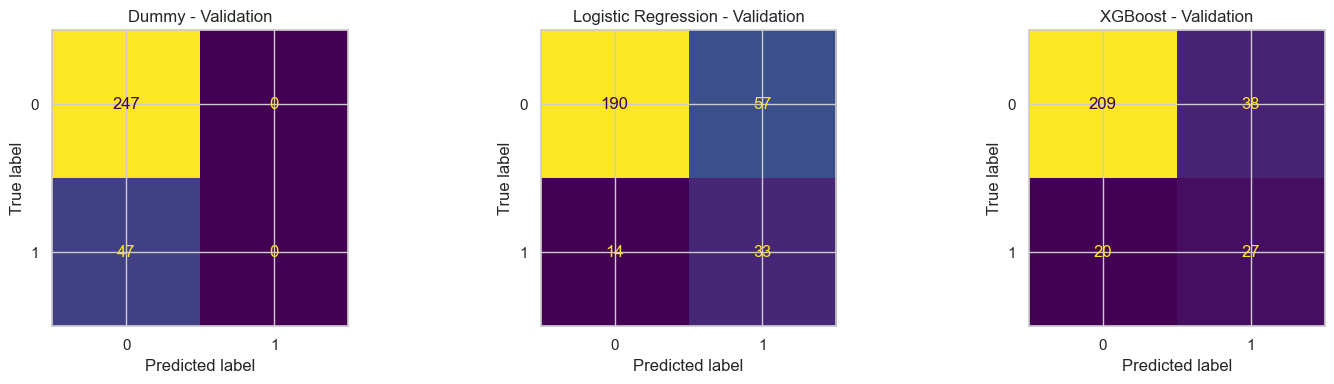

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_val, dummy_val_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Dummy - Validation")

ConfusionMatrixDisplay.from_predictions(y_val, linear_val_pred, ax=axes[1], colorbar=False)
axes[1].set_title("Logistic Regression - Validation")

ConfusionMatrixDisplay.from_predictions(y_val, xgb_val_pred, ax=axes[2], colorbar=False)
axes[2].set_title("XGBoost - Validation")

plt.tight_layout()
plt.show()

## Lecture de l'overfitting

La comparaison entre les performances sur train, validation et test permet d’évaluer la capacité de généralisation des modèles :

- si les scores sont très élevés sur train mais baissent nettement sur validation, le modèle commence à surapprendre
- si les performances sont proches entre validation et test, cela suggère une bonne stabilité
- si le modèle surpasse le Dummy tout en maintenant un bon rappel sur la classe positive, il apporte une vraie valeur opérationnelle

## Interprétation des résultats

Le modèle Dummy obtient une accuracy élevée, mais il échoue totalement à détecter les employés ayant quitté l’entreprise.  
Cela confirme que l’accuracy seule est insuffisante dans un contexte de classes déséquilibrées.

La régression logistique améliore nettement le benchmark Dummy et présente le meilleur rappel sur la classe positive.  
Elle identifie donc davantage d’employés susceptibles de quitter l’entreprise, au prix d’un nombre plus élevé de faux positifs.

Le modèle XGBoost surpasse également le Dummy et présente de meilleures performances globales que celui-ci, mais il reste légèrement en retrait par rapport à la régression logistique sur le jeu de test, notamment en rappel et en F1-score pour la classe positive.

Concernant l’overfitting, XGBoost obtient des scores très élevés sur le jeu d'entraînement, puis des performances plus faibles sur validation et test.  
Ce comportement suggère un certain surapprentissage.

Dans une logique métier RH, le rappel sur la classe positive est particulièrement important, car il mesure la capacité du modèle à identifier les employés à risque de départ.

À ce stade, la régression logistique apparaît donc comme le meilleur compromis.